##### **데이터 준비**

In [1]:
import pandas as pd

# Investment Factor 계산에 필요한 데이터를 input 폴더에서 불러옴
factors          = pd.read_csv("factors_monthly.csv", index_col=0, parse_dates=True)   # 팩터(MKT, SMB, HML, MOM, RF) (독립변수)
factors = factors.pct_change()

In [2]:
# 수익률 분해를 위한 팩터 정리 - 독립변수 설정
factors['MKT'] = factors['KOSPI'] - factors['RF']            # MKT 팩터(시장 포트폴리오 초과 수익률)

---
## **0-2. 포트폴리오 계산**

##### **데이터 로드**

In [3]:
import pandas as pd
import numpy as np

# 포트폴리오 수익률 계산을 위한 총수익률 데이터
total_adj_close  = pd.read_csv("adj close.csv", index_col=0, parse_dates=True)   # 현금배당 반영 수정주가(총수익률 계산)

# 시가총액가중 배분비중 계산 데이터
mkt_cap          = pd.read_csv("mkt cap.csv", index_col=0, parse_dates=True)           # 시가총액

# 거래대금 하위 10% 필터링 계산 데이터
trading_value_60 = pd.read_csv("trading value 60.csv", index_col=0, parse_dates=True)  # 60영업일 평균 거래대금

# Amihud illiquidity 계산 데이터
daily_ret        = total_adj_close.pct_change()         # 일간 수익률 월별 데이터
trading_value    = pd.read_csv("trading value.csv", index_col=0, parse_dates=True).resample('ME').last()     # 월말 거래대금

# --- 기준(마스터) 칼럼: Amihud 월지표 ---
illiq_m = pd.read_csv("illiq_perm_monthly_1.csv", index_col=0, parse_dates=True)
base_cols = illiq_m.columns


def align_columns(df: pd.DataFrame, base_cols: pd.Index) -> pd.DataFrame:
    """
    마스터 칼럼(base_cols)과 공통인 칼럼만 남기고, 칼럼 순서도 base_cols와 동일하게 맞추기.
    """
    common = df.columns.intersection(base_cols)
    aligned = df[common].reindex(columns=base_cols)
    print(aligned.tail())
    return aligned

# --- 칼럼 정렬(축소 + 순서 일치) ---
total_adj_close  = align_columns(total_adj_close,  base_cols)
mkt_cap          = align_columns(mkt_cap,          base_cols)
trading_value_60 = align_columns(trading_value_60, base_cols)
daily_ret        = align_columns(daily_ret,        base_cols)
trading_value    = align_columns(trading_value,    base_cols)

C:\Users\bullh\AppData\Local\Temp\ipykernel_3160\2686190034.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_ret        = total_adj_close.pct_change()         # 일간 수익률 월별 데이터


                삼성전자    SK하이닉스  LG에너지솔루션   삼성바이오로직스  한화에어로스페이스      현대차  \
Date                                                                      
2025-10-27  102000.0  535000.0  495000.0  1208000.0   254500.0  81900.0   
2025-10-28   99500.0  521000.0  510000.0  1232000.0   250500.0  86400.0   
2025-10-29  100500.0  558000.0  514000.0  1221000.0   258000.0  96400.0   
2025-10-30  104100.0  568000.0  486500.0  1221000.0   265000.0  89700.0   
2025-10-31  107500.0  559000.0  473000.0  1221000.0   290000.0  88700.0   

             HD현대중공업         기아      KB금융   두산에너빌리티  ...  웨이포트  성융광전투자  완리  \
Date                                                 ...                     
2025-10-27  624000.0  1039000.0  114800.0  118000.0  ...   NaN     NaN NaN   
2025-10-28  594000.0   996000.0  113600.0  116400.0  ...   NaN     NaN NaN   
2025-10-29  595000.0   993000.0  115800.0  116000.0  ...   NaN     NaN NaN   
2025-10-30  594000.0   994000.0  116200.0  115800.0  ...   NaN     NaN NaN   
2025-1

##### **함수 정의**

In [4]:
from joblib import Parallel, delayed
from tqdm import tqdm

# 함수 정의
def run_strategy(wins_threshold_temp, weight_method_temp, cost_temp,
                 trading_threshold_temp, Amihud_threshold_temp, n_temp):
    
    high_cost, low_cost = cost_temp
    NAV = initial_NAV

    portfolio_name   = f"{weight_method_temp}_R{wins_threshold_temp}_H{int(high_cost*10000)}L{int(low_cost*10000)}_T{trading_threshold_temp}_A{Amihud_threshold_temp}_Q({n_temp+1}/{q_cut})"
    portfolio_return = pd.Series(dtype=float, name=portfolio_name)
    total_trade      = pd.Series(dtype=float, name=portfolio_name)

    # 수익률 윈저라이징
    ret_wins = ret_m.clip(
        lower = ret_m.quantile(wins_threshold_temp),
        upper = ret_m.quantile(1 - wins_threshold_temp),
        axis  = 1
    )

    prev_portfolio = None
    
    for i in range(len(month_ends)-1):
        start_date, end_date = month_ends[i], month_ends[i+1]

        # 거래대금 하위 x% 필터링
        series          = trading_value_60.loc[start_date]
        threshold       = series.quantile(trading_threshold_temp)
        filtered        = series[series > threshold]
        factor_filtered = factor_df.loc[start_date, filtered.index]

        # 종목 선정 (분위수)
        quantiles = pd.qcut(factor_filtered, q=q_cut, labels=False)
        basket    = factor_filtered[quantiles == n_temp]

        if basket.empty:
            continue

        # Amihud illiquidity 계산
        illiq        = (daily_ret.loc[start_date].abs() / trading_value.loc[start_date])
        threshold    = illiq.quantile(1 - Amihud_threshold_temp)
        illiquid_top = illiq[illiq >= threshold].index

        # 이전 비중
        if prev_portfolio is None:
            prev_weights = pd.Series(0, index=basket.index)
        else:
            prev_weights = prev_portfolio / prev_portfolio.sum()

        # 목표 비중
        if weight_method_temp == 'Equal':
            target_weights = pd.Series(1/len(basket), index=basket.index)
        else:  # Cap
            cap_seg = mkt_cap.loc[start_date, basket.index]
            target_weights = cap_seg / cap_seg.sum()

        # 거래비용 반영
        all_index     = target_weights.index.union(prev_weights.index)
        target_w      = target_weights.reindex(all_index, fill_value=0)
        prev_w        = prev_weights.reindex(all_index, fill_value=0)
        delta_w       = target_w - prev_w

        trade_amounts = abs(delta_w) * NAV
        cost_rate     = np.where(delta_w.index.isin(illiquid_top), high_cost, low_cost)
        trade_cost    = (trade_amounts * cost_rate).sum()
        NAV_new       = NAV - trade_cost

        # 포트폴리오 가치
        current_portfolio_value = target_weights * NAV_new
        ret_seg                 = ret_wins.loc[end_date, basket.index]
        next_portfolio_value    = current_portfolio_value * (ret_seg + 1)

        NAV_new       = next_portfolio_value.sum()
        portfolio_ret = NAV_new / NAV - 1

        prev_portfolio = next_portfolio_value
        NAV            = NAV_new

        total_trade.loc[start_date]    = trade_amounts.sum()
        portfolio_return.loc[end_date] = portfolio_ret

    return portfolio_return, total_trade

# 포트폴리오 선택 함수
def select_columns(df, fixed_options):
    selected = []
    new_names = {}
    
    for c in df.columns:
        parts = c.split('_')
        
        # 조건 체크 (고정한 옵션은 정확히 일치해야 함)
        if all(parts[i] == v or v == "*" for i, v in fixed_options.items()):
            selected.append(c)
            
            # 새 이름은 "고정하지 않은 옵션만"
            free_parts = [parts[i] for i, v in fixed_options.items() if v == "*"]
            new_name = "_".join(free_parts)
            new_names[c] = new_name
    
    # 선택된 subset 반환, 컬럼명은 자유 요소만
    subset = df[selected].rename(columns=new_names)
    return subset

---
##### **설정**

In [5]:
# 팩터 설정
factor_df         = -illiq_m

In [6]:
start_point       = '2014-12-31'                     # 백테스트 기간 설정
end_point         = '2025-10-31'

q_cut             = 5                                # 포트폴리오를 나누는 분위 수 e.g. 5 → 5분위 
n                 = [0, 1, 2, 3, 4]                  # 0 : 하위 ~ (q_cut - 1) : 상위    e.g. [0, 1, 2, 3, 4]

weight_method     = ['Equal', 'Cap']                 # ['Equal', Cap']

cost              = [(0.008, 0.003), (0, 0)]         # (high_cost, low_cost)            e.g. [(0.008, 0.003), (0, 0)]
                                                     
wins_threshold    = [0.01, 0.05]                     # 수익률 윈저라이징                 e.g. [0.01, 0.05]
trading_threshold = [0.1, 0.0]                       # 60일 평균 거래대금 필터링         e.g. [0.1, 0.0]
Amihud_threshold  = [0.2, 0.0]                       # 유동성 기준                       e.g. [0.2, 0.0]

initial_NAV       = 1                                # 초기값

##### **계산 실행**

In [7]:
# ret_m        = total_adj_close.resample('QE').last().ffill().pct_change() # 분기 리밸런싱
ret_m        = total_adj_close.resample('ME').last().ffill().pct_change()

portfolio_df = pd.DataFrame()
trade_df     = pd.DataFrame()

month_ends   = factor_df.resample('ME').last().index
month_ends   = month_ends[(month_ends >= pd.to_datetime(start_point)) &
                        (month_ends <= pd.to_datetime(end_point))]

In [8]:
# 모든 조합 만들기
param_list = [
    (wins_threshold_temp, weight_method_temp, cost_temp, trading_threshold_temp, Amihud_threshold_temp, n_temp)
    for wins_threshold_temp in wins_threshold
    for weight_method_temp in weight_method
    for cost_temp in cost
    for trading_threshold_temp in trading_threshold
    for Amihud_threshold_temp in Amihud_threshold
    for n_temp in n
]

# 병렬 실행
results = Parallel(n_jobs=-1)(
    delayed(run_strategy)(*params) for params in tqdm(param_list)
)

# 결과 합치기
portfolio_df = pd.DataFrame({r[0].name: r[0] for r in results})
trade_df     = pd.DataFrame({r[1].name: r[1] for r in results})

100%|██████████| 160/160 [02:30<00:00,  1.06it/s]


In [9]:
portfolio_df.tail()

,Equal_R0.01_H80L30_T0.1_A0.2_Q(1/5),Equal_R0.01_H80L30_T0.1_A0.2_Q(2/5),Equal_R0.01_H80L30_T0.1_A0.2_Q(3/5),Equal_R0.01_H80L30_T0.1_A0.2_Q(4/5),Equal_R0.01_H80L30_T0.1_A0.2_Q(5/5),Equal_R0.01_H80L30_T0.1_A0.0_Q(1/5),Equal_R0.01_H80L30_T0.1_A0.0_Q(2/5),Equal_R0.01_H80L30_T0.1_A0.0_Q(3/5),Equal_R0.01_H80L30_T0.1_A0.0_Q(4/5),Equal_R0.01_H80L30_T0.1_A0.0_Q(5/5),...,Cap_R0.05_H0L0_T0.0_A0.2_Q(1/5),Cap_R0.05_H0L0_T0.0_A0.2_Q(2/5),Cap_R0.05_H0L0_T0.0_A0.2_Q(3/5),Cap_R0.05_H0L0_T0.0_A0.2_Q(4/5),Cap_R0.05_H0L0_T0.0_A0.2_Q(5/5),Cap_R0.05_H0L0_T0.0_A0.0_Q(1/5),Cap_R0.05_H0L0_T0.0_A0.0_Q(2/5),Cap_R0.05_H0L0_T0.0_A0.0_Q(3/5),Cap_R0.05_H0L0_T0.0_A0.0_Q(4/5),Cap_R0.05_H0L0_T0.0_A0.0_Q(5/5)
2025-06-30,0.040371,0.033771,0.035662,0.040038,0.099923,0.040371,0.033771,0.035662,0.040038,0.099923,...,0.029074,0.041731,0.043085,0.046521,0.111857,0.029074,0.041731,0.043085,0.046521,0.111857
2025-07-31,0.013221,0.011236,0.010700,0.000888,0.012620,0.014426,0.012103,0.010966,0.000925,0.012620,...,0.011881,0.007817,0.018018,0.020753,0.052594,0.011881,0.007817,0.018018,0.020753,0.052594
2025-08-31,-0.012529,-0.025933,-0.026011,-0.027139,-0.013178,-0.011457,-0.025008,-0.025680,-0.027003,-0.013178,...,-0.015167,-0.024443,-0.028345,-0.025194,-0.016675,-0.015167,-0.024443,-0.028345,-0.025194,-0.016675
2025-09-30,0.164135,0.176170,0.148423,0.351430,0.241417,0.164135,0.176170,0.148423,0.351430,0.241417,...,0.007671,0.037597,0.044867,0.073800,0.088927,0.007671,0.037597,0.044867,0.073800,0.088927
2025-10-31,-0.032198,-0.017676,-0.003958,0.010268,0.068209,-0.030165,-0.016022,-0.003435,0.010393,0.068222,...,-0.015492,0.019114,0.035131,0.051573,0.147262,-0.015492,0.019114,0.035131,0.051573,0.147262


---
## **1. 분위수 검증**

##### **포트폴리오 선택**

In [10]:
# 기본 : {0: "Equal", 1: "R0.01", 2: "H80L30", 3: "T0.1", 4:"A0.2", 5: "Q(1/5)"}
# -----------------------------
# R: Return winsorization 
# H: High cost(bp)
# L: Low cost(bp)
# T: Trading value
# A: Amihud liquidity
# -----------------------------

subset = select_columns(
    portfolio_df,
    {0: "Equal", 1: "R0.01", 2: "H80L30", 3: "T0.1", 4:"A0.2", 5: "*"}
)

In [11]:
subset.tail()

,Q(1/5),Q(2/5),Q(3/5),Q(4/5),Q(5/5)
2025-06-30,0.040371,0.033771,0.035662,0.040038,0.099923
2025-07-31,0.013221,0.011236,0.010700,0.000888,0.012620
2025-08-31,-0.012529,-0.025933,-0.026011,-0.027139,-0.013178
2025-09-30,0.164135,0.176170,0.148423,0.351430,0.241417
2025-10-31,-0.032198,-0.017676,-0.003958,0.010268,0.068209


##### **Code**

In [12]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors  # 색상 라이브러리 import

# --- 2. 데이터 준비 ---
nav = (subset + 1).cumprod()
log_cum = np.log1p(subset).cumsum()

# --- 3. 엑셀 내보내기 코드 (추가된 부분) ---
# (openpyxl 라이브러리 필요: pip install openpyxl)
excel_filename = "portfolio_performance_data_1.xlsx"
try:
    with pd.ExcelWriter(excel_filename) as writer:
        nav.to_excel(writer, sheet_name='Cumulative_NAV')
        log_cum.to_excel(writer, sheet_name='Log_Cumulative_Return')
    print(f"데이터를 {excel_filename} 파일로 성공적으로 저장했습니다.")
except ImportError:
    print("엑셀 저장을 위해 'openpyxl' 라이브러리가 필요합니다.")
    print("터미널에서 'pip install openpyxl'을 실행해주세요.")
except Exception as e:
    print(f"엑셀 파일 저장 중 오류 발생: {e}")
# --- 엑셀 내보내기 끝 ---


# --- 4. 색상 강제 지정을 위한 color_map 생성 ---
# Plotly의 기본 색상 팔레트 가져오기
default_colors = plotly.colors.DEFAULT_PLOTLY_COLORS
# 컬럼 이름과 색상을 매핑하는 딕셔너리 생성
color_map = {col: default_colors[i % len(default_colors)] for i, col in enumerate(nav.columns)}
# --- 색상 지정 끝 ---


# --- 5. Plotly 그래프 생성 ---
# 서브플롯 (가로 2개)
fig = make_subplots(rows=1, cols=2, subplot_titles=["Cumulative NAV", "Log Cumulative Return"])

# 첫 번째 그래프 (Cumulative NAV)
for col in nav.columns:
    fig.add_trace(
        go.Scatter(x=nav.index, y=nav[col], mode='lines', name=col,
                   legendgroup=col, showlegend=True,
                   line=dict(color=color_map[col])), # <-- 색상 명시적 지정
        row=1, col=1
    )

# 두 번째 그래프 (Log Cumulative Return)
for col in log_cum.columns:
    fig.add_trace(
        go.Scatter(x=log_cum.index, y=log_cum[col], mode='lines', name=col,
                   legendgroup=col, showlegend=False,
                   line=dict(color=color_map[col])), # <-- 색상 명시적 지정
        row=1, col=2
    )

# --- 6. 레이아웃 설정 ---
# 레이아웃 기본 설정
fig.update_layout(
    title="Portfolio Performance Comparison 3-month",
    height=500, width=1000,
    template="plotly_white"
)

# 기존 레이아웃 (Shapes - 테두리)
fig.update_layout(
    shapes=[
        # 왼쪽 그래프 영역 (x=0~0.45, y=0~1)
        dict(type="rect", xref="paper", yref="paper",
             x0=0.0, y0=0.0, x1=0.45, y1=1.0,
             line=dict(color="gray", width=1), fillcolor="rgba(0,0,0,0)"),
        
        # 오른쪽 그래프 영역 (x=0.55~1, y=0~1)
        dict(type="rect", xref="paper", yref="paper",
             x0=0.55, y0=0.0, x1=1.0, y1=1.0,
             line=dict(color="gray", width=1), fillcolor="rgba(0,0,0,0)"),
    ]
)

# --- 7. 그래프 보이기 ---
# jupyter notebook, colab 등에서 그래프를 보려면 아래 줄의 주석을 해제하세요.
# fig.show()

데이터를 portfolio_performance_data_1.xlsx 파일로 성공적으로 저장했습니다.


---
## **2. Double sort : Size Control**

##### **함수**

In [13]:
def run_strategy(c_temp, n_temp,
                 wins_threshold_temp, weight_method_temp, cost_temp,
                 trading_threshold_temp, Amihud_threshold_temp, 
                 initial_NAV=1):
    high_cost, low_cost = cost_temp
    NAV = initial_NAV
    portfolio_name = f"C({c_temp+1}/{cap_cut})_Q({n_temp+1}/{q_cut})"
    
    portfolio_return = pd.Series(dtype=float, name=portfolio_name)
    total_trade      = pd.Series(dtype=float, name=portfolio_name)
    
    # 수익률 윈저라이징
    ret_wins = ret_m.clip(
        lower = ret_m.quantile(wins_threshold_temp),
        upper = ret_m.quantile(1 - wins_threshold_temp),
        axis  = 1
    )
    
    prev_portfolio = None

    for i in range(len(month_ends)-1):
        start_date, end_date = month_ends[i], month_ends[i+1]

        cap_series    = mkt_cap.loc[start_date]
        cap_quantiles = pd.qcut(cap_series, q=cap_cut, labels=False)
        cap_filtered  = cap_series[cap_quantiles == (cap_cut - 1 - c_temp)]

        series    = trading_value_60.loc[start_date, cap_filtered.index]
        threshold = series.quantile(trading_threshold_temp)
        filtered  = series[series > threshold]
        factor_filtered = factor_df.loc[start_date, filtered.index]

        quantiles = pd.qcut(factor_filtered, q=q_cut, labels=False)
        basket    = factor_filtered[quantiles == n_temp]
        if basket.empty:
            continue

        illiq        = (daily_ret.loc[start_date].abs() / trading_value.loc[start_date])
        threshold    = illiq.quantile(1 - Amihud_threshold_temp)
        illiquid_top = illiq[illiq >= threshold].index

        if prev_portfolio is None:
            prev_weights = pd.Series(0, index=basket.index)
        else:
            prev_weights = prev_portfolio / prev_portfolio.sum()

        if weight_method_temp == 'Equal':
            target_weights = pd.Series(1/len(basket), index=basket.index)
        else:  # Cap
            cap_seg = mkt_cap.loc[start_date, basket.index]
            target_weights = cap_seg / cap_seg.sum()

        all_index     = target_weights.index.union(prev_weights.index)
        target_w      = target_weights.reindex(all_index, fill_value=0)
        prev_w        = prev_weights.reindex(all_index, fill_value=0)
        delta_w       = target_w - prev_w

        trade_amounts = abs(delta_w) * NAV
        cost_rate     = np.where(delta_w.index.isin(illiquid_top), high_cost, low_cost)
        trade_cost    = (trade_amounts * cost_rate).sum()
        NAV_new       = NAV - trade_cost

        current_portfolio_value = target_weights * NAV_new
        ret_seg = ret_wins.loc[end_date, basket.index]
        next_portfolio_value = current_portfolio_value * (ret_seg + 1)

        NAV_new       = next_portfolio_value.sum()
        portfolio_ret = NAV_new / NAV - 1

        prev_portfolio = next_portfolio_value
        NAV            = NAV_new

        total_trade.loc[start_date]    = trade_amounts.sum()
        portfolio_return.loc[end_date] = portfolio_ret

    return portfolio_return, total_trade


##### **계산 실행**

In [14]:
cap_cut           = 5                                # 포트폴리오를 나누는 분위 수 e.g. 5 → 5분위 
c                 = [0, 1, 2, 3, 4]    

In [15]:
trading_threshold_temp = trading_threshold[0]
weight_method_temp     = weight_method[0]
cost_temp              = cost[0]
wins_threshold_temp    = wins_threshold[0]
trading_threshold_temp = trading_threshold[0]
Amihud_threshold_temp  = Amihud_threshold[0]

In [16]:
# --- 병렬 실행 ---
results = Parallel(n_jobs=-1)(
    delayed(run_strategy)(
        c_temp, n_temp,
        wins_threshold_temp, weight_method_temp, cost_temp,
        trading_threshold_temp, Amihud_threshold_temp,
        initial_NAV
    )
    for c_temp in c
    for n_temp in n
)

# --- 결과 합치기 ---
cap_cut_profolio_df = pd.DataFrame()
for (portfolio_return, total_trade) in results:
    cap_cut_profolio_df[portfolio_return.name] = portfolio_return

##### **Output**

In [17]:
cap_cut_profolio_df.tail()

,C(1/5)_Q(1/5),C(1/5)_Q(2/5),C(1/5)_Q(3/5),C(1/5)_Q(4/5),C(1/5)_Q(5/5),C(2/5)_Q(1/5),C(2/5)_Q(2/5),C(2/5)_Q(3/5),C(2/5)_Q(4/5),C(2/5)_Q(5/5),...,C(4/5)_Q(1/5),C(4/5)_Q(2/5),C(4/5)_Q(3/5),C(4/5)_Q(4/5),C(4/5)_Q(5/5),C(5/5)_Q(1/5),C(5/5)_Q(2/5),C(5/5)_Q(3/5),C(5/5)_Q(4/5),C(5/5)_Q(5/5)
2025-06-30,0.063661,0.065281,0.083887,0.128446,0.143041,0.021020,0.054918,0.040374,0.026955,0.078458,...,0.036641,0.073150,0.064189,0.021048,0.030921,0.014973,0.053546,0.025228,0.006855,0.009116
2025-07-31,0.028094,0.030280,0.001244,0.020329,0.041696,0.020972,0.042417,0.031047,0.011205,-0.029334,...,0.011708,0.022806,0.008842,0.003912,-0.031282,0.006538,0.009254,0.014392,-0.015513,-0.009478
2025-08-31,-0.028440,0.006838,-0.029766,0.006347,-0.017071,-0.022653,-0.041467,-0.013248,-0.020373,-0.034546,...,-0.015250,-0.037261,-0.031200,-0.020993,-0.023723,0.004313,-0.007767,-0.001574,-0.028822,-0.013857
2025-09-30,0.477449,0.185549,0.131421,0.191660,0.197910,0.113769,0.093577,0.413131,0.178369,0.688980,...,0.116940,0.170408,0.313968,0.206602,0.127875,0.013621,0.089755,0.157419,0.210787,0.161840
2025-10-31,0.034778,0.078771,0.071734,0.065698,0.125727,0.010150,0.045167,0.015026,0.015350,0.036641,...,-0.028530,-0.036695,-0.046934,-0.035131,-0.028673,-0.036321,-0.046497,-0.043820,-0.013676,-0.043578


In [18]:
cap_cut_profolio_df["C(1/5)_Q(1/5)"]

2015-01-31    0.015488
2015-02-28    0.038718
2015-03-31    0.049690
2015-04-30    0.067694
2015-05-31    0.094547
                ...   
2025-06-30    0.063661
2025-07-31    0.028094
2025-08-31   -0.028440
2025-09-30    0.477449
2025-10-31    0.034778
Name: C(1/5)_Q(1/5), Length: 130, dtype: float64

In [19]:
def CAGR(series, periods_per_year=12):
    """월별 수익률 시리즈 기준 CAGR 계산"""
    series = series.dropna()
    if series.empty:
        return np.nan
    cumulative = (1 + series).cumprod()
    start, end = cumulative.index[0], cumulative.index[-1]
    n_years = (end - start).days / 365.25
    return (cumulative.iloc[-1] ** (1 / n_years)) - 1

In [20]:
# heatmap용 DF 초기화
cap_cut = 5
q_cut   = 5
cagr_matrix = pd.DataFrame(index=[f"C({i+1}/{cap_cut})" for i in range(cap_cut)],
                           columns=[f"Q({j+1}/{q_cut})" for j in range(q_cut)])

for col in cap_cut_profolio_df.columns:
    # 이름 parsing: "C(i/5)_Q(j/5)"
    c_part, q_part = col.split('_')
    cagr_matrix.loc[c_part, q_part] = CAGR(cap_cut_profolio_df[col])
    
cagr_matrix = cagr_matrix.astype(float)

In [21]:
import plotly.express as px

fig = px.imshow(
    cagr_matrix.astype(float),
    text_auto=".1%",
    color_continuous_scale="Blues",  # 파란 계열
    aspect="equal",                  # 정사각형 셀
    labels=dict(
        x="Factor Quintile (Q), 3-month", 
        y="Market Cap Quintile (C)", 
        color="CAGR"
    )
)

fig.update_layout(
    title="CAGR Heatmap by Cap vs Factor Quintile",
    xaxis=dict(side="top"),
    width=600,   # 가로 크기
    height=600,  # 세로 크기
    margin=dict(l=60, r=60, t=80, b=60)  # 여백 조정
)

fig.show()

##### **Heatmap**

---
## **3. Parameter Sensitivity**
`0-2. 포트폴리오 계산`에서 계산한 포트폴리오 `portfolio_df` 데이터 사용

---
#### **1) Weight sensitivity**

##### **포트폴리오 선택**

In [22]:
# 기본 : {0: "Equal", 1: "R0.01", 2: "H80L30", 3: "T0.1", 4:"A0.2", 5: "Q(1/5)"}
# -----------------------------
# R: Return winsorization 
# H: High cost(bp)
# L: Low cost(bp)
# T: Trading value
# A: Amihud liquidity
# -----------------------------

# 동일가중 포트폴리오
subset_equal = select_columns(
    portfolio_df,
    {0: "Equal", 1: "R0.01", 2: "H80L30", 3: "T0.1", 4:"A0.2", 5: "*"}
)

# 시총가중 포트폴리오
subset_cap = select_columns(
    portfolio_df,
    {0: "Cap", 1: "R0.01", 2: "H80L30", 3: "T0.1", 4:"A0.2", 5: "*"}
)

##### **Code**

In [23]:
import numpy as np
import pandas as pd  # <-- 1. 엑셀 저장을 위해 import
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors  # <-- 2. 색상 지정을 위해 import

# --- 1. 로그누적수익률 계산 ---
# (이 코드가 실행되기 전에 'subset_equal'과 'subset_cap' DataFrame이
#  이미 정의되어 있어야 합니다)
log_cum_equal = np.log1p(subset_equal).cumsum()
log_cum_cap   = np.log1p(subset_cap).cumsum()

# --- 2. 엑셀 내보내기 코드 (추가된 부분) ---
# (openpyxl 라이브러리 필요: pip install openpyxl)
excel_filename = "equal_vs_cap_data_1.xlsx"
try:
    with pd.ExcelWriter(excel_filename) as writer:
        log_cum_equal.to_excel(writer, sheet_name='Equal_Weighted_LogCum')
        log_cum_cap.to_excel(writer, sheet_name='Cap_Weighted_LogCum')
    print(f"데이터를 {excel_filename} 파일로 성공적으로 저장했습니다.")
except ImportError:
    print("엑셀 저장을 위해 'openpyxl' 라이브러리가 필요합니다.")
    print("터미널에서 'pip install openpyxl'을 실행해주세요.")
except PermissionError: # 'Permission denied' 오류 처리
    print(f"오류: '{excel_filename}' 파일에 대한 쓰기 권한이 없습니다.")
    print("파일이 엑셀 등 다른 프로그램에서 열려 있는지 확인해주세요.")
except Exception as e:
    print(f"엑셀 파일 저장 중 오류 발생: {e}")
# --- 엑셀 내보내기 끝 ---

# --- 3. 색상 강제 지정 (추가된 부분) ---
default_colors = plotly.colors.DEFAULT_PLOTLY_COLORS
# (log_cum_equal의 컬럼을 기준으로 생성)
color_map = {col: default_colors[i % len(default_colors)] for i, col in enumerate(log_cum_equal.columns)}
# --- 색상 지정 끝 ---

# --- 4. Plotly 그래프 생성 ---
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=["Equal-weighted Portfolios", 
                    "Cap-weighted Portfolios"]
)

# Equal 그래프 (색상 지정 추가)
for col in log_cum_equal.columns:
    fig.add_trace(
        go.Scatter(x=log_cum_equal.index, y=log_cum_equal[col], 
                   mode='lines', name=f"Equal_{col}",
                   legendgroup=col, showlegend=True,
                   line=dict(color=color_map[col])), # <-- 색상 명시적 지정
        row=1, col=1
    )

# Cap 그래프 (색상 지정 추가)
for col in log_cum_cap.columns:
    fig.add_trace(
        go.Scatter(x=log_cum_cap.index, y=log_cum_cap[col], 
                   mode='lines', name=f"Cap_{col}",
                   legendgroup=col, showlegend=True,
                   line=dict(color=color_map[col])), # <-- 색상 명시적 지정
        row=1, col=2
    )

# --- 5. 레이아웃 설정 ---
fig.update_layout(
    title="Equal vs Cap Weighted Portfolios (Log Cumulative Returns)",
    height=500, width=1000,
    template="plotly_white"
)

# 각 subplot 테두리 표시
fig.update_layout(
    shapes=[
        dict(type="rect", xref="paper", yref="paper",
             x0=0.0, y0=0.0, x1=0.45, y1=1.0,
             line=dict(color="gray", width=1), fillcolor="rgba(0,0,0,0)"),
        dict(type="rect", xref="paper", yref="paper",
             x0=0.55, y0=0.0, x1=1.0, y1=1.0,
             line=dict(color="gray", width=1), fillcolor="rgba(0,0,0,0)"),
    ]
)

# --- 6. 그래프 보이기 ---
fig.show()

데이터를 equal_vs_cap_data_1.xlsx 파일로 성공적으로 저장했습니다.


---
#### **2) Cost sensitivity**

##### **포트폴리오 선택**

In [24]:
# 기본 : {0: "Equal", 1: "R0.01", 2: "H80L30", 3: "T0.1", 4:"A0.2", 5: "Q(1/5)"}
# -----------------------------
# R: Return winsorization 
# H: High cost(bp)
# L: Low cost(bp)
# T: Trading value
# A: Amihud liquidity
# -----------------------------

# 동일가중 포트폴리오
subset_cost = select_columns(
    portfolio_df,
    {0: "Equal", 1: "R0.01", 2: "*", 3: "T0.1", 4:"A0.2", 5: "Q(1/5)"}
)

##### **Code**

In [25]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# --- 1. 로그누적수익률 계산 ---
log_cum_cost = np.log1p(subset_cost).cumsum()

# --- 2. 엑셀 내보내기 코드 ---
excel_filename = "cost_parameter_data_1.xlsx"
try:
    with pd.ExcelWriter(excel_filename) as writer:
        log_cum_cost.to_excel(writer, sheet_name='LogCum_Cost_Variation')
    print(f"데이터를 {excel_filename} 파일로 성공적으로 저장했습니다.")
except ImportError:
    print("엑셀 저장을 위해 'openpyxl' 라이브러리가 필요합니다.")
    print("터미널에서 'pip install openpyxl'을 실행해주세요.")
except PermissionError: # 'Permission denied' 오류 처리
    print(f"오류: '{excel_filename}' 파일에 대한 쓰기 권한이 없습니다.")
    print("파일이 엑셀 등 다른 프로그램에서 열려 있는지 확인해주세요.")
except Exception as e:
    print(f"엑셀 파일 저장 중 오류 발생: {e}")

# --- 3. Plotly 그래프 생성 ---
# 단일 plot 생성
fig = go.Figure()

for col in log_cum_cost.columns:
    fig.add_trace(
        go.Scatter(
            x=log_cum_cost.index, 
            y=log_cum_cost[col], 
            mode='lines', 
            name=col
        )
    )

# --- 4. 레이아웃 설정 ---
fig.update_layout(
    title="Equal-weighted Portfolios (Cost Parameter Variation, Log Cumulative Return)",
    xaxis_title="Date",
    yaxis_title="Log Cumulative Return",
    template="plotly_white",
    height=600,
    width=900
)

# --- 5. 그래프 보이기 ---
fig.show()

데이터를 cost_parameter_data_1.xlsx 파일로 성공적으로 저장했습니다.


In [26]:
import numpy as np
import pandas as pd  # <-- 1. 엑셀 저장을 위해 import
import plotly.graph_objects as go
# (openpyxl 라이브러리 필요: pip install openpyxl)

# --- 1. 분석 대상 포트폴리오 선택 ---
# 예시: 'Equal_R0.01_H80L30_T0.1_A0.2_Q(1/5)'
port_name = 'Equal_R0.01_H80L30_T0.1_A0.2_Q(1/5)'

# (이 코드가 실행되기 전에 portfolio_df, trade_df, initial_NAV가
#  이미 정의되어 있어야 합니다)

# 선택한 포트폴리오의 수익률 및 거래금액 데이터 추출 (결측치 제거)
portfolio_ret = portfolio_df[port_name].dropna()
trade_value   = trade_df[port_name].dropna()

# --- 2. 리밸런싱 시점의 NAV(순자산가치) 재구성 ---
if len(portfolio_ret) == len(trade_value):
    trade_value.index = portfolio_ret.index
else:
    print("Error: Return-Trade series length mismatch. Check data.")
    # (오류 발생 시 중단을 원하면 raise Exception(...)을 사용할 수 있습니다)

nav_end_series = (1 + portfolio_ret).cumprod() * initial_NAV
nav_start_series = nav_end_series.shift(1).fillna(initial_NAV)
nav_start_series.name = "NAV_Start"

# --- 3. 월간 회전율 계산 ---
monthly_gross_turnover_rate = trade_value / nav_start_series
monthly_one_way_turnover_rate = monthly_gross_turnover_rate / 2
monthly_one_way_turnover_rate.name = "Monthly_OneWay_Turnover"

# 12개월 이동평균 계산
rolling_avg_turnover = monthly_one_way_turnover_rate.rolling(window=12).mean()
rolling_avg_turnover.name = "12M_Rolling_Avg"

# --- 4. 엑셀 내보내기 (추가된 부분) ---
safe_port_name = port_name.replace("/", "_")
excel_filename = f"turnover_data_{safe_port_name}_1.xlsx"

try:
    # 엑셀 저장을 위해 두 Series를 DataFrame으로 결합
    turnover_data_to_save = pd.DataFrame({
        monthly_one_way_turnover_rate.name: monthly_one_way_turnover_rate,
        rolling_avg_turnover.name: rolling_avg_turnover
    })
    
    with pd.ExcelWriter(excel_filename) as writer:
        turnover_data_to_save.to_excel(writer, sheet_name='Monthly_Turnover_Rate')
    print(f"데이터를 {excel_filename} 파일로 성공적으로 저장했습니다.")
except ImportError:
    print("엑셀 저장을 위해 'openpyxl' 라이브러리가 필요합니다.")
    print("터미널에서 'pip install openpyxl'을 실행해주세요.")
except PermissionError: # 'Permission denied' 오류 처리
    print(f"오류: '{excel_filename}' 파일에 대한 쓰기 권한이 없습니다.")
    print("파일이 엑셀 등 다른 프로그램에서 열려 있는지 확인해주세요.")
except Exception as e:
    print(f"엑셀 파일 저장 중 오류 발생: {e}")
# --- 엑셀 내보내기 끝 ---

# --- 5. 회전율 요약 ---
avg_monthly_turnover = monthly_one_way_turnover_rate.mean()
annual_turnover = avg_monthly_turnover * 12

print(f"===== Portfolio Turnover Summary ({port_name}) =====")
print(f"평균 월간 (기간) 회전율 (One-Way): {avg_monthly_turnover * 100:.2f}%")
print(f"연간 회전율 (월간 평균 * 12): {annual_turnover * 100:.2f}%")

# --- 6. 월간 회전율 시각화 ---
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=monthly_one_way_turnover_rate.index[:-1],
        y=monthly_one_way_turnover_rate.iloc[:-1], 
        mode='lines',
        name='월간 회전율 (One-Way)'
    )
)
fig.add_trace(
    go.Scatter(
        x=rolling_avg_turnover.index[:-1], 
        y=rolling_avg_turnover.iloc[:-1],    
        mode='lines',
        name='12개월 이동평균',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(
    title=f"월간 포트폴리오 회전율 (One-Way) - {port_name}",
    xaxis_title="Date",
    yaxis_title="Turnover Rate",
    yaxis_tickformat='.1%', # Y축을 퍼센트(%) 포맷으로 변경
    template="plotly_white",
    height=500,
    width=900
)

fig.show()

데이터를 turnover_data_Equal_R0.01_H80L30_T0.1_A0.2_Q(1_5)_1.xlsx 파일로 성공적으로 저장했습니다.
===== Portfolio Turnover Summary (Equal_R0.01_H80L30_T0.1_A0.2_Q(1/5)) =====
평균 월간 (기간) 회전율 (One-Way): 33.94%
연간 회전율 (월간 평균 * 12): 407.28%


---
## **4. 스프레드 회귀 (Factor regression)**

##### **데이터 로드**

In [27]:
portfolio      = portfolio_df['Equal_R0.01_H80L30_T0.1_A0.2_Q(1/5)']
portfolio.name = 'Return'

##### **함수 정의**

In [28]:
def run_strategy(c_temp, th,
                 wins_threshold_temp, weight_method_temp, cost_temp,
                 trading_threshold_temp, Amihud_threshold_temp, 
                 initial_NAV=1):
    high_cost, low_cost = cost_temp
    NAV = initial_NAV
    portfolio_name = f"C({c_temp+1}/{cap_cut})_Q({th})"
    
    portfolio_return = pd.Series(dtype=float, name=portfolio_name)
    total_trade      = pd.Series(dtype=float, name=portfolio_name)
    
    # 수익률 윈저라이징
    ret_wins = ret_m.clip(
        lower = ret_m.quantile(wins_threshold_temp),
        upper = ret_m.quantile(1 - wins_threshold_temp),
        axis  = 1
    )
    
    prev_portfolio = None

    for i in range(len(month_ends)-1):
        start_date, end_date = month_ends[i], month_ends[i+1]

        cap_series    = mkt_cap.loc[start_date]
        cap_quantiles = pd.qcut(cap_series, q=cap_cut, labels=False)
        cap_filtered  = cap_series[cap_quantiles == c_temp]

        series    = trading_value_60.loc[start_date, cap_filtered.index]
        threshold = series.quantile(trading_threshold_temp)
        filtered  = series[series > threshold]
        factor_filtered = factor_df.loc[start_date, filtered.index]

        low_th  = factor_filtered.quantile(0.3)
        high_th = factor_filtered.quantile(0.7)
        
        if th == 'long':   # IVOL 낮은 그룹
            basket = factor_filtered[factor_filtered <= low_th]
        else:              # IVOL 높은 그룹
            basket = factor_filtered[factor_filtered > high_th]

        illiq        = (daily_ret.loc[start_date].abs() / trading_value.loc[start_date])
        threshold    = illiq.quantile(1 - Amihud_threshold_temp)
        illiquid_top = illiq[illiq >= threshold].index

        if prev_portfolio is None:
            prev_weights = pd.Series(0, index=basket.index)
        else:
            prev_weights = prev_portfolio / prev_portfolio.sum()

        if weight_method_temp == 'Equal':
            target_weights = pd.Series(1/len(basket), index=basket.index)
        else:  # Cap
            cap_seg = mkt_cap.loc[start_date, basket.index]
            target_weights = cap_seg / cap_seg.sum()

        all_index     = target_weights.index.union(prev_weights.index)
        target_w      = target_weights.reindex(all_index, fill_value=0)
        prev_w        = prev_weights.reindex(all_index, fill_value=0)
        delta_w       = target_w - prev_w

        trade_amounts = abs(delta_w) * NAV
        cost_rate     = np.where(delta_w.index.isin(illiquid_top), high_cost, low_cost)
        trade_cost    = (trade_amounts * cost_rate).sum()
        NAV_new       = NAV - trade_cost

        current_portfolio_value = target_weights * NAV_new
        ret_seg = ret_wins.loc[end_date, basket.index]
        next_portfolio_value = current_portfolio_value * (ret_seg + 1)

        NAV_new       = next_portfolio_value.sum()
        portfolio_ret = NAV_new / NAV - 1

        prev_portfolio = next_portfolio_value
        NAV            = NAV_new

        total_trade.loc[start_date]    = trade_amounts.sum()
        portfolio_return.loc[end_date] = portfolio_ret

    return portfolio_return, total_trade

##### **계산**

In [29]:
cap_cut           = 2                                # 포트폴리오를 나누는 분위 수 e.g. 5 → 5분위 
c                 = [0, 1]    

In [30]:
trading_threshold_temp = trading_threshold[0]
weight_method_temp     = weight_method[0]
cost_temp              = cost[0]
wins_threshold_temp    = wins_threshold[0]
trading_threshold_temp = trading_threshold[0]
Amihud_threshold_temp  = Amihud_threshold[0]

In [31]:
th = 'long'
results_long = Parallel(n_jobs=-1)(
    delayed(run_strategy)(
        c_temp, th,
        wins_threshold_temp, weight_method_temp, cost_temp,
        trading_threshold_temp, Amihud_threshold_temp,
        initial_NAV
    )
    for c_temp in c
)

th = 'short'
results_short = Parallel(n_jobs=-1)(
    delayed(run_strategy)(
        c_temp, th,
        wins_threshold_temp, weight_method_temp, cost_temp,
        trading_threshold_temp, Amihud_threshold_temp,
        initial_NAV
    )
    for c_temp in c
)

factor_portfolio_df = pd.DataFrame()

# Long 결과 추가
for (portfolio_return, total_trade) in results_long:
    factor_portfolio_df[portfolio_return.name] = portfolio_return

# Short 결과 추가
for (portfolio_return, total_trade) in results_short:
    factor_portfolio_df[portfolio_return.name] = portfolio_return

In [32]:
factor_portfolio_df.tail()

,C(1/2)_Q(long),C(2/2)_Q(long),C(1/2)_Q(short),C(2/2)_Q(short)
2025-06-30,0.043078,0.040811,0.032135,0.114919
2025-07-31,0.012792,0.021652,-0.014351,0.018507
2025-08-31,-0.000837,-0.027392,-0.030861,-0.014331
2025-09-30,0.123555,0.141550,0.176429,0.261640
2025-10-31,-0.038152,0.017087,-0.025643,0.080325


In [33]:
# long-short 스프레드 계산
small_ls = factor_portfolio_df["C(1/2)_Q(long)"] - factor_portfolio_df["C(1/2)_Q(short)"]
big_ls   = factor_portfolio_df["C(2/2)_Q(long)"] - factor_portfolio_df["C(2/2)_Q(short)"]

# 두 그룹 평균 → 최종 factor return
factor_return = (small_ls + big_ls) / 2
factor_return.name = "Factor"

##### **Output : ivol 팩터 포트폴리오** 

In [34]:
factor_return

2015-01-31   -0.026479
2015-02-28    0.045103
2015-03-31    0.034775
2015-04-30    0.003772
2015-05-31   -0.000382
                ...   
2025-06-30   -0.031583
2025-07-31    0.015144
2025-08-31    0.008482
2025-09-30   -0.086482
2025-10-31   -0.037874
Name: Factor, Length: 130, dtype: float64

##### **회귀분석**

##### **Code**

In [35]:
# 1. 두 데이터 공통 구간 맞추기
import statsmodels.api as sm

df = pd.concat([portfolio, factors], axis=1, join="inner").dropna()

In [36]:
df

,Return,KOSPI,HML,SMB,MOM,RF,MKT
2015-01-31,0.058346,0.017577,-0.047920,0.046427,0.054878,-0.004695,0.022272
2015-02-28,0.096698,0.018746,0.035670,0.061558,-0.018076,-0.009434,0.028180
2015-03-31,0.073422,0.027812,0.007229,0.057626,0.042174,-0.119048,0.146860
2015-04-30,0.051903,0.042204,0.002537,0.012061,0.018498,-0.027027,0.069231
2015-05-31,0.016135,-0.005815,-0.054315,0.065078,0.080759,0.000000,-0.005815
...,...,...,...,...,...,...,...
2025-06-30,0.040371,0.138649,0.028903,-0.067961,0.011075,-0.011583,0.150232
2025-07-31,0.013221,0.056562,-0.025323,-0.043851,-0.064316,-0.019531,0.076093
2025-08-31,-0.012529,-0.018312,-0.001854,-0.002987,-0.008658,0.007968,-0.026280
2025-09-30,0.164135,0.074887,-0.030251,-0.038333,0.001916,0.015810,0.059076


In [37]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     1358.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          6.31e-102
Time:                        18:02:49   Log-Likelihood:                 317.00
No. Observations:                 130   AIC:                            -624.0
Df Residuals:                     125   BIC:                            -609.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0075      0.001      8.754      0.0

In [38]:
# 1. 회귀분석 기간을 2025-08-31까지로 제한
new_df = df.loc[df.index <= '2025-10-31']

# 2. 종속변수 (new_df 기반)
y_new = new_df['Return'] - new_df['RF']

# 3. 독립변수 (new_df 기반)
X_new = pd.DataFrame({
    "MKT": new_df['KOSPI'] - new_df['RF'],
    "SMB": new_df['SMB'],
    "HML": new_df['HML'],
    "MOM": new_df['MOM']
}, index=new_df.index)

X_new = sm.add_constant(X_new, has_constant='add')

# 4. OLS 회귀 (new_df 기반)
model_new = sm.OLS(y_new, X_new).fit(cov_type="HAC", cov_kwds={"maxlags":12}) # Newey-West

print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     1358.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          6.31e-102
Time:                        18:02:49   Log-Likelihood:                 317.00
No. Observations:                 130   AIC:                            -624.0
Df Residuals:                     125   BIC:                            -609.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0075      0.001      8.754      0.0


--- 잔차 이상치 (Z-Score의 절댓값 > 2.5) ---
총 2개의 이상치 발견:
2025-09-30    0.123480
2025-10-31   -0.076872
Freq: ME, dtype: float64

--- 엑셀 저장 완료 ---
잔차 분석 데이터가 'residual_analysis_1.xlsx' 파일로 저장되었습니다.

--- 잔차 시각화 생성 중... ---


C:\Users\bullh\AppData\Local\Temp\ipykernel_3160\753343287.py:93: UserWarning:

Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.

C:\Users\bullh\AppData\Local\Temp\ipykernel_3160\753343287.py:93: UserWarning:

Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.

C:\Users\bullh\AppData\Local\Temp\ipykernel_3160\753343287.py:93: UserWarning:

Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.

C:\Users\bullh\AppData\Local\Temp\ipykernel_3160\753343287.py:93: UserWarning:

Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.

C:\Users\bullh\AppData\Local\Temp\ipykernel_3160\753343287.py:93: UserWarning:

Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.

C:\Users\bullh\AppData\Local\Temp\ipykernel_3160\753343287.py:93: UserWarning:

Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.

C:\Users\bullh\AppData\Local\Temp\ipykernel_3160\753343287.py:93: UserWarning:

Gl

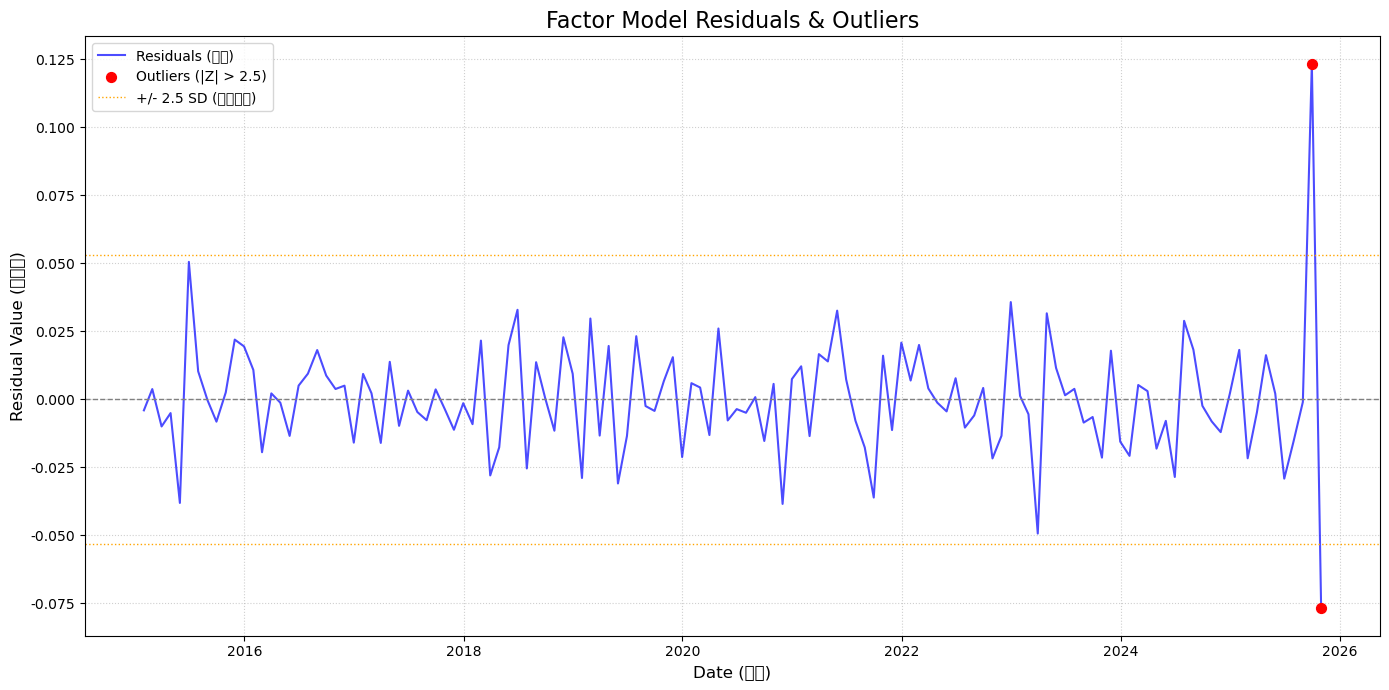

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 5. 잔차(Residuals) 추출
# model.resid는 회귀분석에 사용된 데이터의 인덱스를 그대로 가집니다.
residuals = model.resid

# 6. 잔차의 Z-Score 계산
# Z-Score = (개별 잔차 - 잔차 평균) / 잔차 표준편차
# OLS 잔차의 평균은 0에 매우 가깝습니다.
resid_mean = residuals.mean()
resid_std = residuals.std()
z_scores = (residuals - resid_mean) / resid_std

# 7. 이상치 탐색 (예: Z-Score의 절댓값이 2.5 이상인 경우)
# 이 임계값(threshold)은 필요에 따라 2.0 또는 3.0 등으로 조정할 수 있습니다.
threshold = 2.5 
outliers = residuals[np.abs(z_scores) > threshold]

print("\n" + "="*50)
print(f"--- 잔차 이상치 (Z-Score의 절댓값 > {threshold}) ---")
if outliers.empty:
    print("지정된 임계값을 초과하는 잔차 이상치가 없습니다.")
else:
    print(f"총 {len(outliers)}개의 이상치 발견:")
    print(outliers)
print("="*50 + "\n")

# 7-1. 엑셀로 내보낼 데이터프레임 생성
# 전체 잔차(Residual), Z-Score, 
# 그리고 이상치(Outlier)에 해당되는 값만 표시하는 열을 만듭니다.
# 'outliers' Series는 이상치만 값을 가지므로, 
# DataFrame에 합치면 나머지는 NaN으로 채워집니다.
df_export = pd.DataFrame({
    'Residual': residuals,
    'Z-Score': z_scores,
    'Outlier_Value': outliers 
})

# 7-2. 엑셀 파일로 저장

excel_filename = 'residual_analysis_1.xlsx'

try:
    # pandas의 to_excel 함수를 사용하여 저장합니다.
    # index=True로 설정하여 날짜 인덱스도 함께 저장합니다.
    df_export.to_excel(excel_filename, index=True, sheet_name='Residuals')
    
    print(f"--- 엑셀 저장 완료 ---")
    print(f"잔차 분석 데이터가 '{excel_filename}' 파일로 저장되었습니다.")
    print("="*50 + "\n")

except ImportError:
    print("\n--- 엑셀 저장 오류 ---")
    print("엑셀 저장을 위해서는 'openpyxl' 라이브러리가 필요합니다.")
    print("터미널(Tearminal)이나 명령 프롬프트(cmd)에서 아래 명령어를 실행해주세요:")
    print("pip install openpyxl")
    print("="*50 + "\n")
except Exception as e:
    print(f"\n--- 엑셀 저장 중 예외 발생 ---")
    print(f"오류: {e}")
    print("="*50 + "\n")

# 8. 잔차 시각화 (이상치 표시)
print("--- 잔차 시각화 생성 중... ---")
plt.figure(figsize=(14, 7))

# 한국어 폰트 설정 (만약 깨진다면 주석 처리 후 폰트 설치 필요)
# plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 전체 잔차 플롯 (라인)
plt.plot(residuals.index, residuals, label='Residuals (잔차)', color='blue', alpha=0.7, linewidth=1.5)

# 이상치 플롯 (붉은색 점)
plt.scatter(outliers.index, outliers, color='red', label=f'Outliers (|Z| > {threshold})', zorder=5, s=50)

# 0 기준선
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Z-Score 임계값 기준선 (선택 사항)
upper_limit = threshold * resid_std
lower_limit = -threshold * resid_std
plt.axhline(upper_limit, color='orange', linestyle=':', linewidth=1, label=f'+/- {threshold} SD (표준편차)')
plt.axhline(lower_limit, color='orange', linestyle=':', linewidth=1)

plt.title('Factor Model Residuals & Outliers', fontsize=16)
plt.xlabel('Date (날짜)', fontsize=12)
plt.ylabel('Residual Value (잔차값)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout() # 그래프 여백 자동 조절

# 그래프 보이기
plt.show()

---

##### **Code**

In [40]:
# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([portfolio, factors], axis=1, join="inner").dropna()

# factor_return 추가
df["Factor"] = factor_return.loc[df.index]

# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM, MyFactor
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM'],
    "Factor": df["Factor"]
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     1195.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          4.75e-103
Time:                        18:02:52   Log-Likelihood:                 319.18
No. Observations:                 130   AIC:                            -626.4
Df Residuals:                     124   BIC:                            -609.2
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0055      0.003      1.811      0.0

In [41]:
# 1. 회귀분석 기간을 2025-08-31까지로 제한
new_df = df.loc[df.index <= '2025-10-31']

# 2. 종속변수 (new_df 기반)
y_new = new_df['Return'] - new_df['RF']

# 3. 독립변수 (new_df 기반, Factor 포함)
X_new = pd.DataFrame({
    "MKT": new_df['KOSPI'] - new_df['RF'],
    "SMB": new_df['SMB'],
    "HML": new_df['HML'],
    "MOM": new_df['MOM'],
    "Factor": new_df["Factor"]
}, index=new_df.index)

X_new = sm.add_constant(X_new, has_constant='add')

# 4. OLS 회귀 (new_df 기반)
model_new = sm.OLS(y_new, X_new).fit(cov_type="HAC", cov_kwds={"maxlags":12}) # Newey-West

print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     1195.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          4.75e-103
Time:                        18:02:52   Log-Likelihood:                 319.18
No. Observations:                 130   AIC:                            -626.4
Df Residuals:                     124   BIC:                            -609.2
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0055      0.003      1.811      0.0

---
## **5. Subsample Test**

In [42]:
import numpy as np
import pandas as pd

def print_performance_summary(series: pd.Series, name: str = "Portfolio", periods_per_year: int = 12):
    """
    월별 수익률 Series를 받아 주요 성과 지표(CAGR, Ann. Vol, Sharpe, MDD)를 계산하고 출력합니다.
    """
    
    # .dropna()를 통해 계산 가능한 유효한 데이터만 사용합니다.
    series = series.dropna()
    
    if series.empty:
        print(f"===== Performance Summary: {name} =====")
        print("Data is empty. Cannot calculate metrics.")
        print("-" * 40)
        return

    # 1. 누적수익률
    cum_ret = (1 + series).cumprod()

    # 2. 전체 기간 (년)
    n_months = len(series)
    n_years = n_months / periods_per_year
    
    # 기간이 1년 미만일 경우 CAGR 계산이 왜곡될 수 있으므로 별도 처리
    if n_years < 1:
        print(f"Warning: Data period ({n_years:.2f} years) is less than 1 year. CAGR may not be representative.")
        # 1년 미만일 경우, 연율화 대신 총 수익률을 표시하거나 단순 연율화를 할 수 있습니다.
        # 여기서는 총 수익률을 기반으로 연율화합니다.
        cagr = (cum_ret.iloc[-1])**(1/n_years) - 1
    else:
        cagr = (cum_ret.iloc[-1])**(1/n_years) - 1


    # 3. Annualized Volatility (연변동성)
    ann_vol = series.std() * np.sqrt(periods_per_year)

    # 4. Annualized Return (산술 연평균 수익률 - Sharpe용)
    ann_ret = series.mean() * periods_per_year

    # 5. Sharpe Ratio (무위험수익률 0 가정)
    # 변동성이 0에 가까워 0으로 나누는 것을 방지
    if ann_vol < 1e-8:
        sharpe = np.nan
    else:
        sharpe = ann_ret / ann_vol

    # 6. MDD (최대 낙폭)
    roll_max = cum_ret.cummax()
    drawdown = cum_ret / roll_max - 1
    mdd = drawdown.min()

    # 7. 요약 출력
    print(f"===== Performance Summary: {name} =====")
    print(f"Start Date:               {series.index[0].strftime('%Y-%m-%d')}")
    print(f"End Date:                 {series.index[-1].strftime('%Y-%m-%d')}")
    print(f"Total Months:             {n_months}")
    print("-" * 40)
    print(f"CAGR:                     {cagr*100:.2f}%")
    print(f"Annualized Volatility:    {ann_vol*100:.2f}%")
    print(f"Annualized Return (Arith):{ann_ret*100:.2f}%")
    print(f"Sharpe Ratio (Rf=0):      {sharpe:.2f}")
    print(f"Maximum Drawdown (MDD):   {mdd*100:.2f}%")
    print("-" * 40)

In [43]:
# --- 방금 전 회귀분석에 사용한 변수들을 기준으로 성과를 계산합니다 ---

# 1. 회귀분석의 종속변수(Y)로 사용된 'Q(1/5)' 포트폴리오 성과
# (회귀분석에서 공통 기간으로 필터링된 'y' 변수 사용)
print_performance_summary(portfolio, name="Q(1/5) Portfolio (Raw Return)")

# 2. 새로 생성한 'Factor' (Long-Short) 포트폴리오 성과
# (회귀분석에서 공통 기간으로 필터링된 'df["Factor"]' 사용)
print_performance_summary(df["Factor"], name="Illiquidity Factor (L-S)")

===== Performance Summary: Q(1/5) Portfolio (Raw Return) =====
Start Date:               2015-01-31
End Date:                 2025-10-31
Total Months:             130
----------------------------------------
CAGR:                     16.38%
Annualized Volatility:    20.90%
Annualized Return (Arith):17.44%
Sharpe Ratio (Rf=0):      0.83
Maximum Drawdown (MDD):   -23.25%
----------------------------------------
===== Performance Summary: Illiquidity Factor (L-S) =====
Start Date:               2015-01-31
End Date:                 2025-10-31
Total Months:             130
----------------------------------------
CAGR:                     12.45%
Annualized Volatility:    7.68%
Annualized Return (Arith):12.08%
Sharpe Ratio (Rf=0):      1.57
Maximum Drawdown (MDD):   -12.86%
----------------------------------------


In [44]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# --- 1. 데이터 준비 ---
# 비교할 포트폴리오 이름
port_name = 'Equal_R0.01_H80L30_T0.1_A0.2_Q(1/5)'

# 포트폴리오 월별 수익률
port_ret = portfolio_df[port_name].copy()
port_ret.name = 'Portfolio'

# KOSPI 월별 수익률 ('0-1. 팩터 로드' 섹션에서 계산된 'factors' DataFrame 사용)
# factors = pd.read_csv("factors_monthly.csv", ...).pct_change()
kospi_ret = factors['KOSPI'].copy()
kospi_ret.name = 'KOSPI'

# --- 2. 데이터 정렬 및 누적 수익률 계산 ---
# 두 수익률 시리즈의 공통 기간으로 DataFrame 생성
compare_df = pd.concat([port_ret, kospi_ret], axis=1, join='inner').dropna()

# 누적 수익률 (NAV) 계산
compare_nav = (1 + compare_df).cumprod()

# --- 3. 엑셀 내보내기 ---
excel_filename = "portfolio_vs_kospi_data_1.xlsx"
try:
    with pd.ExcelWriter(excel_filename) as writer:
        compare_nav.to_excel(writer, sheet_name='Cumulative_NAV')
        compare_df.to_excel(writer, sheet_name='Monthly_Returns')
    print(f"데이터를 {excel_filename} 파일로 성공적으로 저장했습니다.")
except ImportError:
    print("엑셀 저장을 위해 'openpyxl' 라이브러리가 필요합니다.")
    print("터미널에서 'pip install openpyxl'을 실행해주세요.")
except PermissionError: # 'Permission denied' 오류 처리
    print(f"오류: '{excel_filename}' 파일에 대한 쓰기 권한이 없습니다.")
    print("파일이 엑셀 등 다른 프로그램에서 열려 있는지 확인해주세요.")
except Exception as e:
    print(f"엑셀 파일 저장 중 오류 발생: {e}")

# --- 4. Plotly 그래프 생성 ---
fig = go.Figure()

# 포트폴리오 누적 수익률
fig.add_trace(
    go.Scatter(
        x=compare_nav.index,
        y=compare_nav['Portfolio'],
        mode='lines',
        name=f'Portfolio ({port_name})',
        line=dict(color='blue', width=2)
    )
)

# KOSPI 누적 수익률
fig.add_trace(
    go.Scatter(
        x=compare_nav.index,
        y=compare_nav['KOSPI'],
        mode='lines',
        name='KOSPI',
        line=dict(color='gray', width=1.5)
    )
)

# --- 5. 레이아웃 설정 ---
fig.update_layout(
    title="Portfolio vs. KOSPI - Cumulative Return Comparison",
    xaxis_title="Date",
    yaxis_title="Cumulative Return (NAV)",
    template="plotly_white",
    height=500,
    width=900,
    legend_title="Series"
)

# --- 6. 그래프 보이기 ---
fig.show()

데이터를 portfolio_vs_kospi_data_1.xlsx 파일로 성공적으로 저장했습니다.
